# Final Analysis — All Methods, All Sizes, Paper-Ready

Comprehensive analysis of all KD experiments for paper writing.

## Sections
- **A**: Load all judge files into master DataFrame
- **B**: Method × size aggregations with % of teacher
- **C**: Headline tables (top methods, per-family best)
- **D**: Form-over-substance analysis — the paper's core finding
- **E**: Size scaling evidence (clinical_correctness vs frozen base capacity)
- **F**: Per-question analysis (difficulty, discriminability, winners)
- **G**: Failure case extraction (low clinical_correctness questions)
- **H**: Statistical significance (paired t-tests)
- **I**: Publication-ready plots

## Coverage
- E-series: E0–E7 (9 methods, all 3 sizes)
- M v1: M1–M7 (7 methods, all 3 sizes)
- M v2: 9 M1v2 combos + 6 M2v2 orderings + M3v2 + M4 metric-guided
- Raw baseline + Teacher (Gemini 2.5 Pro)

## Section A — Load all judge files into master DataFrame

In [28]:
# Cell A0: Config + paths
import os, json, glob, re, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
# PROJECT_DIR = os.path.expanduser("~/kd_project")

DATA_DIR = os.path.join(PROJECT_DIR, "data")
N_EVAL = 100

METRIC_COLS = ["decision_accuracy", "safety_score", "clinical_correctness",
               "completeness", "coherence", "format_compliance"]
COMP5_COLS = ["decision_accuracy", "safety_score", "clinical_correctness", "completeness", "coherence"]
REASONING_COLS = ["clinical_correctness", "completeness", "coherence"]

SIZE_MAP = {
    "qwen25_1p5b_base": "1.5B",
    "qwen25_3b_base":   "3B",
    "qwen25_7b_base":   "7B",
}
SIZE_ORDER = ["1.5B", "3B", "7B"]

# Method display names + family grouping
METHOD_DISPLAY = {
    # E-series
    "e0_sft_adapted":              ("E0 SFT",              "E-series"),
    "e1_wsft_adapted":             ("E1 WSFT",             "E-series"),
    "e2_cwsft_adapted":            ("E2 CW-SFT",           "E-series"),
    "e3_cwwsft_adapted":           ("E3 CW-WSFT",          "E-series"),
    "e4_section_cw_wsft":          ("E4 Section CW-WSFT",  "E-series"),
    "e5a_decision_entropy_sft":    ("E5a Dec Entropy",     "E-series"),
    "e5b_explanation_entropy_sft": ("E5b Expl Entropy",    "E-series"),
    "e6_explanation_only_sft":     ("E6 Expl Only",        "E-series"),
    "e7_decision_only_sft":        ("E7 Dec Only",         "E-series"),
    # M v1
    # "m1_additive_multi_loss":      ("M1 Additive",         "M v1"),
    # "m2_anti_curriculum":          ("M2 Anti-Curriculum",  "M v1"),
    "m3_juggler":                  ("M3 Juggler",          "M v1"),
    # "m4_token_confidence_routing": ("M4 Token Conf",       "M v1"),
    # "m5_section_routed":           ("M5 Section Routed",   "M v1"),
    # "m6_lora_merging":             ("M6 LoRA Merge",       "M v1"),
    # "m7_warmstart_from_e7":        ("M7 Warmstart",        "M v1"),
    # M1v2 — 9 configs
    **{f"m1v2_{c}": (f"M1v2 {c}", "M1v2 Additive") for c in ["A1"]},
    # M2v2 — 6 orderings
    **{f"m2v2_{o}": (f"M2v2 {o}", "M2v2 Sequential") for o in ["WDE","WED","EDW","EWD"]},
    # M3v2 / M4
    "m3v2_juggler":                ("M3v2 Juggler",        "M3v2 Juggler"),
    # "m4_metric_guided":            ("M4 Metric-Guided",    "M4 Metric-Guided"),
    # Baseline
    "raw_baseline":                ("Raw Baseline",        "Baseline"),
}

print(f"Project dir: {PROJECT_DIR}")
print(f"Methods registered: {len(METHOD_DISPLAY)}")

Project dir: C:\Users\adishalit1\Desktop\kd_project
Methods registered: 17


In [29]:
# Cell A1: Auto-discover all judge files (handles __g31 and non-__g31 naming)
def find_judge_file(stub, prefer_g31=True):
    """Look for judge file. Prefer __g31 suffix if available."""
    candidates = [
        f"judge__{stub}__{N_EVAL}__g31.jsonl",
        f"judge__{stub}__{N_EVAL}.jsonl",
    ]
    if not prefer_g31:
        candidates.reverse()
    for c in candidates:
        path = os.path.join(DATA_DIR, c)
        if os.path.exists(path):
            return path
    return None

judge_files = {}
missing = []
for stub in METHOD_DISPLAY:
    path = find_judge_file(stub)
    if path:
        judge_files[stub] = path
    else:
        missing.append(stub)

# Teacher file (no method stub)
teacher_path = None
for c in [f"judge__teacher__{N_EVAL}__g31.jsonl", f"judge__teacher__{N_EVAL}.jsonl"]:
    p = os.path.join(DATA_DIR, c)
    if os.path.exists(p):
        teacher_path = p
        break

print(f"✅ Found judge files: {len(judge_files)}")
print(f"✅ Teacher: {teacher_path}")
if missing:
    print(f"\n⚠️ Missing ({len(missing)}):")
    for m in missing:
        print(f"   {m}")

✅ Found judge files: 17
✅ Teacher: C:\Users\adishalit1\Desktop\kd_project\data\judge__teacher__100.jsonl


In [30]:
# Cell A2: Load teacher scores
def load_judge_jsonl(path):
    """Returns list of (id, model, scores_dict) tuples for status='ok' records."""
    out = []
    if not path or not os.path.exists(path):
        return out
    for line in open(path):
        try:
            obj = json.loads(line)
        except:
            continue
        if obj.get("status") != "ok":
            continue
        for mn, sc in obj.get("scores", {}).items():
            if isinstance(sc, dict):
                out.append((obj["id"], mn, sc))
    return out

# Teacher
teacher_rows = []
if teacher_path:
    for sid, mn, sc in load_judge_jsonl(teacher_path):
        if mn == "teacher":  # only the teacher row
            rec = {"id": sid}
            for c in METRIC_COLS:
                if c in sc:
                    rec[c] = float(sc[c])
            teacher_rows.append(rec)

teacher_df = pd.DataFrame(teacher_rows)
print(f"Teacher: {len(teacher_df)} questions")

teacher_mean = {c: teacher_df[c].mean() if c in teacher_df else 0 for c in METRIC_COLS}
teacher_mean["reasoning_mean"] = np.mean([teacher_mean[c] for c in REASONING_COLS])
teacher_mean["composite_5"] = np.mean([teacher_mean[c] for c in COMP5_COLS])

print("\n=== TEACHER (Gemini 2.5 Pro) MEAN SCORES ===")
for k, v in teacher_mean.items():
    print(f"  {k:25s}: {v:.3f}")

Teacher: 100 questions

=== TEACHER (Gemini 2.5 Pro) MEAN SCORES ===
  decision_accuracy        : 4.350
  safety_score             : 4.240
  clinical_correctness     : 4.220
  completeness             : 3.130
  coherence                : 3.650
  format_compliance        : 3.660
  reasoning_mean           : 3.667
  composite_5              : 3.918


In [31]:
# Cell A3: Load all method scores into master DataFrame
master_rows = []
for stub, path in judge_files.items():
    display_name, family = METHOD_DISPLAY[stub]
    for sid, mn, sc in load_judge_jsonl(path):
        if mn not in SIZE_MAP:
            continue  # skip non-base or unknown
        rec = {
            "id": sid,
            "stub": stub,
            "method": display_name,
            "family": family,
            "model": mn,
            "size": SIZE_MAP[mn],
        }
        for c in METRIC_COLS:
            if c in sc:
                rec[c] = float(sc[c])
        master_rows.append(rec)

master_df = pd.DataFrame(master_rows)
master_df["reasoning_mean"] = master_df[REASONING_COLS].mean(axis=1)
master_df["composite_5"] = master_df[COMP5_COLS].mean(axis=1)

# Add per-question teacher reference (for paired analysis later)
teacher_lookup = teacher_df.set_index("id") if not teacher_df.empty else None

print(f"Master DataFrame: {len(master_df)} score rows")
print(f"Methods: {master_df['method'].nunique()}")
print(f"Families: {sorted(master_df['family'].unique())}")
print(f"Sizes per method:")
for m in sorted(master_df['method'].unique()):
    sizes = sorted(master_df[master_df['method']==m]['size'].unique(), key=lambda s: SIZE_ORDER.index(s))
    print(f"  {m:25s}: {sizes}")

Master DataFrame: 4958 score rows
Methods: 17
Families: ['Baseline', 'E-series', 'M v1', 'M1v2 Additive', 'M2v2 Sequential', 'M3v2 Juggler']
Sizes per method:
  E0 SFT                   : ['1.5B', '3B', '7B']
  E1 WSFT                  : ['1.5B', '3B', '7B']
  E2 CW-SFT                : ['1.5B', '3B', '7B']
  E3 CW-WSFT               : ['1.5B', '3B', '7B']
  E4 Section CW-WSFT       : ['1.5B', '3B', '7B']
  E5a Dec Entropy          : ['1.5B', '3B', '7B']
  E5b Expl Entropy         : ['1.5B', '3B', '7B']
  E6 Expl Only             : ['1.5B', '3B', '7B']
  E7 Dec Only              : ['1.5B', '3B', '7B']
  M1v2 A1                  : ['1.5B', '3B']
  M2v2 EDW                 : ['1.5B', '3B', '7B']
  M2v2 EWD                 : ['1.5B', '3B', '7B']
  M2v2 WDE                 : ['1.5B', '3B', '7B']
  M2v2 WED                 : ['1.5B', '3B', '7B']
  M3 Juggler               : ['1.5B', '3B', '7B']
  M3v2 Juggler             : ['1.5B', '3B', '7B']
  Raw Baseline             : ['1.5B', '3B', '7B

## Section B — Method × Size Aggregations

Computes mean scores per (method, size) and % of teacher per metric.
The % of teacher is **per-metric**, so it correctly reflects which metrics
beat the teacher and which lag.

In [32]:
# Cell B0: Aggregate to (method, size) means
agg = master_df.groupby(["family", "method", "size"])[METRIC_COLS].mean()
agg["reasoning_mean"] = agg[REASONING_COLS].mean(axis=1)
agg["composite_5"] = agg[COMP5_COLS].mean(axis=1)
agg["n_samples"] = master_df.groupby(["family", "method", "size"]).size()

print(f"Aggregated table: {len(agg)} (method, size) combinations")
display(agg.round(3).head(15))

Aggregated table: 50 (method, size) combinations


decision_accuracy  safety_score  \
family   method       size                                    
Baseline Raw Baseline 1.5B              2.900         1.870   
                      3B                3.650         2.850   
                      7B                4.150         3.360   
E-series E0 SFT       1.5B              3.990         2.465   
                      3B                4.040         2.727   
                      7B                4.141         3.485   
         E1 WSFT      1.5B              4.192         2.869   
                      3B                4.242         3.131   
                      7B                4.293         3.727   
         E2 CW-SFT    1.5B              4.150         2.870   
                      3B                4.150         3.070   
                      7B                4.300         3.640   
         E3 CW-WSFT   1.5B              4.141         2.677   
                      3B                4.242         3.182   
                      7B                4.293         3.727   

                            clinical_correctness  completeness  coherence  \
family   method       size                                                  
Baseline Raw Baseline 1.5B                 0.690         1.850      2.880   
                      3B                   1.910         2.390      3.590   
                      7B                   2.390         2.770      4.090   
E-series E0 SFT       1.5B                 1.020         2.253      3.364   
                      3B                   1.465         2.525      3.626   
                      7B                   2.566         3.293      4.192   
         E1 WSFT      1.5B                 1.424         2.566      3.545   
                      3B                   1.949         2.879      3.929   
                      7B                   2.909         3.525      4.374   
         E2 CW-SFT    1.5B                 1.450         2.620      3.680   
                      3B                   1.800         2.840      3.870   
                      7B                   2.690         3.490      4.280   
         E3 CW-WSFT   1.5B                 1.293         2.495      3.535   
                      3B                   1.970         2.919      3.929   
                      7B                   2.798         3.485      4.374   

                            format_compliance  reasoning_mean  composite_5  \
family   method       size                                                   
Baseline Raw Baseline 1.5B              1.120           1.807        2.038   
                      3B                3.100           2.630        2.878   
                      7B                2.480           3.083        3.352   
E-series E0 SFT       1.5B              5.000           2.212        2.618   
                      3B                4.990           2.539        2.877   
                      7B                5.000           3.350        3.535   
         E1 WSFT      1.5B              4.980           2.512        2.919   
                      3B                4.949           2.919        3.226   
                      7B                4.980           3.603        3.766   
         E2 CW-SFT    1.5B              4.960           2.583        2.954   
                      3B                4.940           2.837        3.146   
                      7B                4.950           3.487        3.680   
         E3 CW-WSFT   1.5B              4.980           2.441        2.828   
                      3B                4.980           2.939        3.248   
                      7B                4.990           3.552        3.735   

                            n_samples  
family   method       size             
Baseline Raw Baseline 1.5B        100  
                      3B          100  
                      7B          100  
E-series E0 SFT       1.5B         99  
                      3B           99  
                      7B           99  

In [33]:
# Cell B1: % of teacher (per-metric normalization — robust version)
pct = agg.copy()
for c in METRIC_COLS:
    if teacher_mean[c] > 0:
        pct[c] = (agg[c] / teacher_mean[c] * 100).round(1)
    else:
        pct[c] = np.nan
pct["reasoning_mean"] = (agg["reasoning_mean"] / teacher_mean["reasoning_mean"] * 100).round(1)
pct["composite_5"] = (agg["composite_5"] / teacher_mean["composite_5"] * 100).round(1)
pct = pct.drop(columns=["n_samples"])

print("Per-metric % of teacher (>100 = beats teacher, <100 = lags)")
print(f"Teacher means: " + " ".join(f"{c[:4]}={teacher_mean[c]:.2f}" for c in METRIC_COLS))
display(pct.round(1).head(15))

Per-metric % of teacher (>100 = beats teacher, <100 = lags)
Teacher means: deci=4.35 safe=4.24 clin=4.22 comp=3.13 cohe=3.65 form=3.66


decision_accuracy  safety_score  \
family   method       size                                    
Baseline Raw Baseline 1.5B               66.7          44.1   
                      3B                 83.9          67.2   
                      7B                 95.4          79.2   
E-series E0 SFT       1.5B               91.7          58.1   
                      3B                 92.9          64.3   
                      7B                 95.2          82.2   
         E1 WSFT      1.5B               96.4          67.7   
                      3B                 97.5          73.9   
                      7B                 98.7          87.9   
         E2 CW-SFT    1.5B               95.4          67.7   
                      3B                 95.4          72.4   
                      7B                 98.9          85.8   
         E3 CW-WSFT   1.5B               95.2          63.1   
                      3B                 97.5          75.0   
                      7B                 98.7          87.9   

                            clinical_correctness  completeness  coherence  \
family   method       size                                                  
Baseline Raw Baseline 1.5B                  16.4          59.1       78.9   
                      3B                    45.3          76.4       98.4   
                      7B                    56.6          88.5      112.1   
E-series E0 SFT       1.5B                  24.2          72.0       92.2   
                      3B                    34.7          80.7       99.3   
                      7B                    60.8         105.2      114.8   
         E1 WSFT      1.5B                  33.7          82.0       97.1   
                      3B                    46.2          92.0      107.7   
                      7B                    68.9         112.6      119.8   
         E2 CW-SFT    1.5B                  34.4          83.7      100.8   
                      3B                    42.7          90.7      106.0   
                      7B                    63.7         111.5      117.3   
         E3 CW-WSFT   1.5B                  30.6          79.7       96.9   
                      3B                    46.7          93.3      107.7   
                      7B                    66.3         111.3      119.8   

                            format_compliance  reasoning_mean  composite_5  
family   method       size                                                  
Baseline Raw Baseline 1.5B               30.6            49.3         52.0  
                      3B                 84.7            71.7         73.5  
                      7B                 67.8            84.1         85.6  
E-series E0 SFT       1.5B              136.6            60.3         66.8  
                      3B                136.3            69.2         73.4  
                      7B                136.6            91.4         90.2  
         E1 WSFT      1.5B              136.1            68.5         74.5  
                      3B                135.2            79.6         82.3  
                      7B                136.1            98.3         96.1  
         E2 CW-SFT    1.5B              135.5            70.5         75.4  
                      3B                135.0            77.4         80.3  
                      7B                135.2            95.1         93.9  
         E3 CW-WSFT   1.5B              136.1            66.6         72.2  
                      3B                136.1            80.2         82.9  
                      7B                136.3            96.9         95.3

## Section C — Headline Tables for the Paper

In [34]:
# Cell C0: Top 10 overall (by composite_5)
flat = agg.reset_index()
flat["pct_of_teacher"] = (flat["composite_5"] / teacher_mean["composite_5"] * 100).round(1)
top10 = flat.sort_values("composite_5", ascending=False).head(10)

print("="*90)
print("  TOP 10 OVERALL — by composite_5")
print(f"  (teacher composite_5 = {teacher_mean['composite_5']:.3f})")
print("="*90)
display(top10[["family","method","size","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS].round(3))

top10.to_csv(os.path.join(DATA_DIR, "paper_top10.csv"), index=False)
print(f"\nSaved → paper_top10.csv")

  TOP 10 OVERALL — by composite_5
  (teacher composite_5 = 3.918)


,family,method,size,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
29,E-series,E7 Dec Only,7B,3.766,3.647,96.1,4.150,3.740,2.870,3.730,4.340,4.99
8,E-series,E1 WSFT,7B,3.766,3.603,96.1,4.293,3.727,2.909,3.525,4.374,4.98
23,E-series,E5b Expl Entropy,7B,3.740,3.543,95.5,4.350,3.720,2.750,3.570,4.310,5.00
14,E-series,E3 CW-WSFT,7B,3.735,3.552,95.3,4.293,3.727,2.798,3.485,4.374,4.99
46,M2v2 Sequential,M2v2 WED,7B,3.721,3.539,95.0,4.293,3.697,2.778,3.475,4.364,4.96
20,E-series,E5a Dec Entropy,7B,3.717,3.562,94.9,4.192,3.707,2.778,3.525,4.384,4.97
17,E-series,E4 Section CW-WSFT,7B,3.685,3.529,94.0,4.192,3.646,2.778,3.465,4.343,4.99
11,E-series,E2 CW-SFT,7B,3.680,3.487,93.9,4.300,3.640,2.690,3.490,4.280,4.95
37,M2v2 Sequential,M2v2 EDW,7B,3.673,3.475,93.7,4.293,3.646,2.646,3.455,4.323,4.98
40,M2v2 Sequential,M2v2 EWD,7B,3.671,3.488,93.7,4.242,3.646,2.687,3.364,4.414,4.99



Saved → paper_top10.csv


In [35]:
# Cell C1: Best per family
best_per_family = []
for family in flat["family"].unique():
    fdf = flat[flat["family"] == family]
    if fdf.empty: continue
    best_idx = fdf["composite_5"].idxmax()
    row = fdf.loc[best_idx].copy()
    best_per_family.append(row)

bpf = pd.DataFrame(best_per_family).sort_values("composite_5", ascending=False)
bpf["pct_of_teacher"] = (bpf["composite_5"] / teacher_mean["composite_5"] * 100).round(1)

print("="*90)
print("  BEST PER FAMILY (best size + best config from each method family)")
print("="*90)
display(bpf[["family","method","size","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS].round(3))

bpf.to_csv(os.path.join(DATA_DIR, "paper_best_per_family.csv"), index=False)
print(f"\nSaved → paper_best_per_family.csv")

  BEST PER FAMILY (best size + best config from each method family)


,family,method,size,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
29,E-series,E7 Dec Only,7B,3.766,3.647,96.1,4.150,3.740,2.870,3.730,4.340,4.990
46,M2v2 Sequential,M2v2 WED,7B,3.721,3.539,95.0,4.293,3.697,2.778,3.475,4.364,4.960
32,M v1,M3 Juggler,7B,3.449,3.289,88.0,4.031,3.347,2.429,3.204,4.235,4.969
49,M3v2 Juggler,M3v2 Juggler,7B,3.422,3.228,87.4,4.031,3.398,2.347,3.122,4.214,4.990
2,Baseline,Raw Baseline,7B,3.352,3.083,85.6,4.150,3.360,2.390,2.770,4.090,2.480
34,M1v2 Additive,M1v2 A1,3B,3.052,2.690,77.9,4.150,3.040,1.760,2.670,3.640,4.970



Saved → paper_best_per_family.csv


In [36]:
# Cell C2: Top per size
print("="*90)
print("  TOP 10 PER MODEL SIZE")
print(f"  (teacher composite_5 = {teacher_mean['composite_5']:.3f})")
print("="*90)
for size in SIZE_ORDER:
    sub = flat[flat["size"] == size].sort_values("composite_5", ascending=False).head(10)
    if sub.empty: continue
    print(f"\n--- {size} ---")
    display(sub[["family","method","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS].round(3))

  TOP 10 PER MODEL SIZE
  (teacher composite_5 = 3.918)

--- 1.5B ---


,family,method,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
27,E-series,E7 Dec Only,3.008,2.583,76.8,4.350,2.940,1.680,2.570,3.500,0.01
21,E-series,E5b Expl Entropy,2.964,2.567,75.7,4.150,2.970,1.480,2.600,3.620,5.00
9,E-series,E2 CW-SFT,2.954,2.583,75.4,4.150,2.870,1.450,2.620,3.680,4.96
6,E-series,E1 WSFT,2.919,2.512,74.5,4.192,2.869,1.424,2.566,3.545,4.98
18,E-series,E5a Dec Entropy,2.917,2.545,74.5,4.141,2.808,1.404,2.566,3.667,4.97
38,M2v2 Sequential,M2v2 EWD,2.907,2.549,74.2,4.091,2.798,1.455,2.525,3.667,5.00
15,E-series,E4 Section CW-WSFT,2.887,2.572,73.7,3.990,2.727,1.525,2.576,3.616,4.99
24,E-series,E6 Expl Only,2.869,2.575,73.2,3.878,2.745,1.653,2.602,3.469,0.00
44,M2v2 Sequential,M2v2 WED,2.861,2.535,73.0,4.040,2.657,1.364,2.576,3.667,5.00
12,E-series,E3 CW-WSFT,2.828,2.441,72.2,4.141,2.677,1.293,2.495,3.535,4.98



--- 3B ---


,family,method,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
28,E-series,E7 Dec Only,3.398,3.197,86.7,4.100,3.300,2.240,3.350,4.000,4.990
25,E-series,E6 Expl Only,3.339,3.163,85.2,4.082,3.122,2.184,3.245,4.061,4.990
22,E-series,E5b Expl Entropy,3.314,2.997,84.6,4.300,3.280,2.070,3.000,3.920,4.940
13,E-series,E3 CW-WSFT,3.248,2.939,82.9,4.242,3.182,1.970,2.919,3.929,4.980
7,E-series,E1 WSFT,3.226,2.919,82.3,4.242,3.131,1.949,2.879,3.929,4.949
19,E-series,E5a Dec Entropy,3.200,2.879,81.7,4.192,3.172,1.929,2.869,3.838,4.939
39,M2v2 Sequential,M2v2 EWD,3.196,2.855,81.6,4.192,3.222,1.869,2.758,3.939,5.000
42,M2v2 Sequential,M2v2 WDE,3.158,2.817,80.6,4.250,3.090,1.730,2.890,3.830,4.990
10,E-series,E2 CW-SFT,3.146,2.837,80.3,4.150,3.070,1.800,2.840,3.870,4.940
45,M2v2 Sequential,M2v2 WED,3.143,2.852,80.2,4.091,3.071,1.798,2.848,3.909,4.990



--- 7B ---


,family,method,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
29,E-series,E7 Dec Only,3.766,3.647,96.1,4.150,3.740,2.870,3.730,4.340,4.99
8,E-series,E1 WSFT,3.766,3.603,96.1,4.293,3.727,2.909,3.525,4.374,4.98
23,E-series,E5b Expl Entropy,3.740,3.543,95.5,4.350,3.720,2.750,3.570,4.310,5.00
14,E-series,E3 CW-WSFT,3.735,3.552,95.3,4.293,3.727,2.798,3.485,4.374,4.99
46,M2v2 Sequential,M2v2 WED,3.721,3.539,95.0,4.293,3.697,2.778,3.475,4.364,4.96
20,E-series,E5a Dec Entropy,3.717,3.562,94.9,4.192,3.707,2.778,3.525,4.384,4.97
17,E-series,E4 Section CW-WSFT,3.685,3.529,94.0,4.192,3.646,2.778,3.465,4.343,4.99
11,E-series,E2 CW-SFT,3.680,3.487,93.9,4.300,3.640,2.690,3.490,4.280,4.95
37,M2v2 Sequential,M2v2 EDW,3.673,3.475,93.7,4.293,3.646,2.646,3.455,4.323,4.98
40,M2v2 Sequential,M2v2 EWD,3.671,3.488,93.7,4.242,3.646,2.687,3.364,4.414,4.99


## Section D — Form-over-Substance Analysis (PAPER CORE)

The headline finding: students exceed teacher on structural metrics (format, coherence, completeness)
but lag substantially on factual metrics (clinical_correctness, safety).

This pattern is consistent across **all methods** and **all sizes**, suggesting
an architectural bottleneck rather than an algorithmic one.

In [37]:
# Cell D0: Headline table — best 7B vs teacher per metric
best_7b = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).head(1)
if not best_7b.empty:
    best_method = best_7b.iloc[0]["method"]
    best_family = best_7b.iloc[0]["family"]
    print(f"Best 7B method: {best_method} ({best_family})")
    print()
    
    # Build comparison table
    comparison = pd.DataFrame({
        "Teacher (Gemini 2.5)": [teacher_mean[c] for c in METRIC_COLS + ["reasoning_mean", "composite_5"]],
        f"Best Student 7B ({best_method})": [
            best_7b.iloc[0][c] for c in METRIC_COLS + ["reasoning_mean", "composite_5"]
        ],
    }, index=METRIC_COLS + ["reasoning_mean", "composite_5"])
    comparison["% of Teacher"] = (comparison.iloc[:, 1] / comparison.iloc[:, 0] * 100).round(1)
    comparison["Beats teacher?"] = comparison["% of Teacher"].apply(lambda x: "✅" if x > 100 else "❌")
    
    print("="*90)
    print(f"  HEADLINE TABLE — Best 7B Student vs Teacher")
    print("="*90)
    display(comparison.round(3))
    
    # Save this — it's the paper's headline table
    comparison.to_csv(os.path.join(DATA_DIR, "PAPER_HEADLINE_form_over_substance.csv"))
    print(f"\n✅ Saved → PAPER_HEADLINE_form_over_substance.csv")

Best 7B method: E7 Dec Only (E-series)

  HEADLINE TABLE — Best 7B Student vs Teacher


,Teacher (Gemini 2.5),Best Student 7B (E7 Dec Only),% of Teacher,Beats teacher?
decision_accuracy,4.350,4.150,95.4,❌
safety_score,4.240,3.740,88.2,❌
clinical_correctness,4.220,2.870,68.0,❌
completeness,3.130,3.730,119.2,✅
coherence,3.650,4.340,118.9,✅
format_compliance,3.660,4.990,136.3,✅
reasoning_mean,3.667,3.647,99.5,❌
composite_5,3.918,3.766,96.1,❌



✅ Saved → PAPER_HEADLINE_form_over_substance.csv


In [38]:
# Cell D1: Form-over-substance pattern across ALL methods
# For each (method, size), count how many metrics exceed teacher vs lag
beats = []
for _, row in flat.iterrows():
    rec = {"family": row["family"], "method": row["method"], "size": row["size"]}
    for c in METRIC_COLS:
        rec[f"{c}_pct"] = (row[c] / teacher_mean[c] * 100) if teacher_mean[c] > 0 else 0
        rec[f"{c}_beats"] = 1 if row[c] > teacher_mean[c] else 0
    rec["n_metrics_beat"] = sum(rec[f"{c}_beats"] for c in METRIC_COLS)
    rec["composite_5_pct"] = (row["composite_5"] / teacher_mean["composite_5"] * 100)
    beats.append(rec)

beats_df = pd.DataFrame(beats)

# Which metrics get beaten how often (across all methods × sizes)?
print("="*90)
print("  HOW OFTEN DOES EACH METRIC BEAT TEACHER (across all method × size combos)")
print("="*90)
metric_beat_summary = pd.DataFrame({
    "metric": METRIC_COLS,
    "teacher_mean": [teacher_mean[c] for c in METRIC_COLS],
    "n_combos_beating": [beats_df[f"{c}_beats"].sum() for c in METRIC_COLS],
    "pct_combos_beating": [(beats_df[f"{c}_beats"].sum() / len(beats_df) * 100) for c in METRIC_COLS],
    "mean_pct_of_teacher": [beats_df[f"{c}_pct"].mean() for c in METRIC_COLS],
    "min_pct_of_teacher": [beats_df[f"{c}_pct"].min() for c in METRIC_COLS],
    "max_pct_of_teacher": [beats_df[f"{c}_pct"].max() for c in METRIC_COLS],
}).set_index("metric")
display(metric_beat_summary.round(2))

print("\n→ Notice: format_compliance, coherence, completeness usually >100% of teacher")
print("→ clinical_correctness and safety_score <100% across virtually all methods")
print("→ This is the form-over-substance gap")
metric_beat_summary.to_csv(os.path.join(DATA_DIR, "form_over_substance_per_metric.csv"))

  HOW OFTEN DOES EACH METRIC BEAT TEACHER (across all method × size combos)


,teacher_mean,n_combos_beating,pct_combos_beating,mean_pct_of_teacher,min_pct_of_teacher,max_pct_of_teacher
metric,,,,,,
decision_accuracy,4.35,0,0.0,94.52,66.67,100.00
safety_score,4.24,0,0.0,73.18,44.10,88.21
clinical_correctness,4.22,0,0.0,45.70,16.35,68.94
completeness,3.13,16,32.0,92.19,59.11,119.17
coherence,3.65,34,68.0,106.01,78.90,120.94
format_compliance,3.66,45,90.0,126.09,0.00,136.61



→ Notice: format_compliance, coherence, completeness usually >100% of teacher
→ clinical_correctness and safety_score <100% across virtually all methods
→ This is the form-over-substance gap


In [39]:
# Cell D2: Per-method form-over-substance "shape"
# For each (method, size), classify whether each metric beats or lags teacher
# Then count how many methods have the SAME pattern (all 17+ methods should show the same shape)
print("="*90)
print("  FORM-vs-SUBSTANCE SHAPE — % of teacher per metric, per method/size")
print(f"  (Sorted by composite_5 descending, top 20 shown)")
print("="*90)
shape_df = flat.copy()
for c in METRIC_COLS:
    shape_df[c] = (shape_df[c] / teacher_mean[c] * 100).round(1)
shape_df["composite_5_pct"] = (shape_df["composite_5"] / teacher_mean["composite_5"] * 100).round(1)
shape_df = shape_df.sort_values("composite_5_pct", ascending=False).head(20)

display(shape_df[["family","method","size"] + METRIC_COLS + ["composite_5_pct"]].round(1))
print("\nLook at columns left-to-right:")
print("  decision_accuracy:    high (~90-100% — task is structurally inferable)")
print("  safety_score:         medium (~60-90% — partly structural, partly factual)")
print("  clinical_correctness: LOW (~25-70% — purely factual)")
print("  completeness:         high (~80-115% — structural)")
print("  coherence:            high (~95-125% — structural)")
print("  format_compliance:    very high (~130-140% — purely structural)")

  FORM-vs-SUBSTANCE SHAPE — % of teacher per metric, per method/size
  (Sorted by composite_5 descending, top 20 shown)


,family,method,size,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,composite_5_pct
8,E-series,E1 WSFT,7B,98.7,87.9,68.9,112.6,119.8,136.1,96.1
29,E-series,E7 Dec Only,7B,95.4,88.2,68.0,119.2,118.9,136.3,96.1
23,E-series,E5b Expl Entropy,7B,100.0,87.7,65.2,114.1,118.1,136.6,95.5
14,E-series,E3 CW-WSFT,7B,98.7,87.9,66.3,111.3,119.8,136.3,95.3
46,M2v2 Sequential,M2v2 WED,7B,98.7,87.2,65.8,111.0,119.6,135.5,95.0
20,E-series,E5a Dec Entropy,7B,96.4,87.4,65.8,112.6,120.1,135.8,94.9
17,E-series,E4 Section CW-WSFT,7B,96.4,86.0,65.8,110.7,119.0,136.3,94.0
11,E-series,E2 CW-SFT,7B,98.9,85.8,63.7,111.5,117.3,135.2,93.9
40,M2v2 Sequential,M2v2 EWD,7B,97.5,86.0,63.7,107.5,120.9,136.3,93.7
37,M2v2 Sequential,M2v2 EDW,7B,98.7,86.0,62.7,110.4,118.4,136.1,93.7



Look at columns left-to-right:
  decision_accuracy:    high (~90-100% — task is structurally inferable)
  safety_score:         medium (~60-90% — partly structural, partly factual)
  clinical_correctness: LOW (~25-70% — purely factual)
  completeness:         high (~80-115% — structural)
  coherence:            high (~95-125% — structural)
  format_compliance:    very high (~130-140% — purely structural)


## Section E — Size Scaling Analysis (key MLP evidence)

If facts live in frozen MLP layers (Geva 2021, Dai 2022, Meng 2022) and your LoRA only
adapts attention, then clinical_correctness should scale **monotonically** with frozen base
size — because larger frozen MLPs hold more pretrained pharmacology knowledge.

Conversely, format_compliance should be roughly **flat** across sizes — because attention
LoRA adaptation is similar at all sizes.

This is the core mechanistic evidence for the paper.

In [40]:
# Cell E0: Per-method size scaling
print("="*90)
print("  SIZE SCALING — selected metrics across 1.5B → 3B → 7B")
print("="*90)

# For each method, get all 3 sizes
scaling_rows = []
for method in flat["method"].unique():
    mdf = flat[flat["method"] == method]
    if mdf["size"].nunique() < 2:
        continue  # need at least 2 sizes
    rec = {"method": method, "family": mdf.iloc[0]["family"]}
    for size in SIZE_ORDER:
        srow = mdf[mdf["size"] == size]
        if not srow.empty:
            rec[f"{size}_clin"] = srow.iloc[0]["clinical_correctness"]
            rec[f"{size}_fmt"] = srow.iloc[0]["format_compliance"]
            rec[f"{size}_safe"] = srow.iloc[0]["safety_score"]
            rec[f"{size}_comp5"] = srow.iloc[0]["composite_5"]
    scaling_rows.append(rec)

scaling_df = pd.DataFrame(scaling_rows)

# Show methods that have all 3 sizes
full_scaling = scaling_df.dropna(subset=["1.5B_clin", "3B_clin", "7B_clin"])
print(f"\nMethods with all 3 sizes: {len(full_scaling)}")

# Compute scaling slopes (improvement per size step)
full_scaling["clin_growth_3to7"] = full_scaling["7B_clin"] - full_scaling["3B_clin"]
full_scaling["fmt_growth_3to7"] = full_scaling["7B_fmt"] - full_scaling["3B_fmt"]
full_scaling["safe_growth_3to7"] = full_scaling["7B_safe"] - full_scaling["3B_safe"]

display(full_scaling.sort_values("7B_clin", ascending=False).round(3))

print("\n=== SUMMARY: average growth from 3B → 7B ===")
print(f"  clinical_correctness: +{full_scaling['clin_growth_3to7'].mean():.3f} (HIGH growth — facts in larger MLPs)")
print(f"  format_compliance:    +{full_scaling['fmt_growth_3to7'].mean():.3f} (LOW growth — attention LoRA saturates)")
print(f"  safety_score:         +{full_scaling['safe_growth_3to7'].mean():.3f} (medium — both structural + factual)")
print("\n→ This is exactly what the form-over-substance hypothesis predicts.")
full_scaling.to_csv(os.path.join(DATA_DIR, "size_scaling.csv"))

  SIZE SCALING — selected metrics across 1.5B → 3B → 7B

Methods with all 3 sizes: 16


,method,family,1.5B_clin,1.5B_fmt,1.5B_safe,1.5B_comp5,3B_clin,3B_fmt,3B_safe,3B_comp5,7B_clin,7B_fmt,7B_safe,7B_comp5,clin_growth_3to7,fmt_growth_3to7,safe_growth_3to7
2,E1 WSFT,E-series,1.424,4.980,2.869,2.919,1.949,4.949,3.131,3.226,2.909,4.980,3.727,3.766,0.960,0.03,0.596
9,E7 Dec Only,E-series,1.680,0.010,2.940,3.008,2.240,4.990,3.300,3.398,2.870,4.990,3.740,3.766,0.630,0.00,0.440
4,E3 CW-WSFT,E-series,1.293,4.980,2.677,2.828,1.970,4.980,3.182,3.248,2.798,4.990,3.727,3.735,0.828,0.01,0.545
5,E4 Section CW-WSFT,E-series,1.525,4.990,2.727,2.887,1.808,4.990,3.020,3.129,2.778,4.990,3.646,3.685,0.970,0.00,0.626
15,M2v2 WED,M2v2 Sequential,1.364,5.000,2.657,2.861,1.798,4.990,3.071,3.143,2.778,4.960,3.697,3.721,0.980,-0.03,0.626
6,E5a Dec Entropy,E-series,1.404,4.970,2.808,2.917,1.929,4.939,3.172,3.200,2.778,4.970,3.707,3.717,0.848,0.03,0.535
7,E5b Expl Entropy,E-series,1.480,5.000,2.970,2.964,2.070,4.940,3.280,3.314,2.750,5.000,3.720,3.740,0.680,0.06,0.440
3,E2 CW-SFT,E-series,1.450,4.960,2.870,2.954,1.800,4.940,3.070,3.146,2.690,4.950,3.640,3.680,0.890,0.01,0.570
13,M2v2 EWD,M2v2 Sequential,1.455,5.000,2.798,2.907,1.869,5.000,3.222,3.196,2.687,4.990,3.646,3.671,0.818,-0.01,0.424
12,M2v2 EDW,M2v2 Sequential,1.313,4.970,2.667,2.802,1.758,4.980,2.949,3.119,2.646,4.980,3.646,3.673,0.889,0.00,0.697



=== SUMMARY: average growth from 3B → 7B ===
  clinical_correctness: +0.787 (HIGH growth — facts in larger MLPs)
  format_compliance:    +-0.031 (LOW growth — attention LoRA saturates)
  safety_score:         +0.523 (medium — both structural + factual)

→ This is exactly what the form-over-substance hypothesis predicts.


## Section F — Per-Question Analysis

How does each question score across all methods + teacher?
- Which questions are "hard" (low teacher score)?
- Which questions are "discriminating" (high variance across methods)?
- Per-question best/worst method

In [41]:
# Cell F0: Per-question stats
# Build a long DataFrame: id × (method, size) → composite_5
master_df["method_size"] = master_df["method"] + " " + master_df["size"]

per_q = master_df.groupby("id").agg(
    n_method_size=("composite_5", "count"),
    mean_comp5=("composite_5", "mean"),
    std_comp5=("composite_5", "std"),
    min_comp5=("composite_5", "min"),
    max_comp5=("composite_5", "max"),
    mean_clin=("clinical_correctness", "mean"),
    mean_safe=("safety_score", "mean"),
).round(3)

# Add teacher score
if teacher_lookup is not None:
    per_q = per_q.join(teacher_lookup[METRIC_COLS].rename(columns={c: f"teacher_{c}" for c in METRIC_COLS}))
    per_q["teacher_comp5"] = per_q[[f"teacher_{c}" for c in COMP5_COLS]].mean(axis=1).round(3)
    per_q["teacher_clin"] = per_q["teacher_clinical_correctness"]

print(f"Per-question stats: {len(per_q)} questions")
print(f"\nMean across questions:")
print(f"  Mean comp5 (students): {per_q['mean_comp5'].mean():.3f}")
print(f"  Std comp5 (across methods, mean over questions): {per_q['std_comp5'].mean():.3f}")
if "teacher_comp5" in per_q.columns:
    print(f"  Teacher comp5: {per_q['teacher_comp5'].mean():.3f}")

print(f"\nQuestion difficulty range:")
print(f"  Easiest 5 questions (highest mean student comp5):")
display(per_q.sort_values("mean_comp5", ascending=False).head(5)[["mean_comp5","std_comp5","teacher_comp5","mean_clin"]] if "teacher_comp5" in per_q.columns else per_q.sort_values("mean_comp5", ascending=False).head(5)[["mean_comp5","std_comp5","mean_clin"]])

print(f"\n  Hardest 5 questions (lowest mean student comp5):")
display(per_q.sort_values("mean_comp5", ascending=True).head(5)[["mean_comp5","std_comp5","teacher_comp5","mean_clin"]] if "teacher_comp5" in per_q.columns else per_q.sort_values("mean_comp5", ascending=True).head(5)[["mean_comp5","std_comp5","mean_clin"]])

Per-question stats: 100 questions

Mean across questions:
  Mean comp5 (students): 3.173
  Std comp5 (across methods, mean over questions): 0.802
  Teacher comp5: 3.918

Question difficulty range:
  Easiest 5 questions (highest mean student comp5):


,mean_comp5,std_comp5,teacher_comp5,mean_clin
id,,,,
371502766078,4.712,0.734,5.0,4.44
7c82226ae9f4,4.612,0.754,5.0,4.30
34c80145071f,4.580,0.815,5.0,4.24
ab886b7c7098,4.484,0.745,3.8,3.90
10cae754ca63,4.472,0.703,5.0,3.96



  Hardest 5 questions (lowest mean student comp5):


,mean_comp5,std_comp5,teacher_comp5,mean_clin
id,,,,
c1f258c4caf2,1.124,0.305,2.2,0.000
59e9ed7d75db,1.316,0.408,3.8,1.360
b70d0a5f1994,1.356,0.526,2.6,0.160
c2e5657b8bcf,1.388,0.458,1.4,0.540
704ac1a7e86d,1.400,0.286,1.6,0.319


In [42]:
# Cell F1: Most "discriminating" questions (highest std across methods)
# These are useful for paper appendix — showing where method choice matters most
print("="*90)
print("  MOST DISCRIMINATING QUESTIONS (highest std across methods/sizes)")
print("  These questions discriminate best between methods")
print("="*90)
most_discriminating = per_q.sort_values("std_comp5", ascending=False).head(10)
display(most_discriminating[["mean_comp5","std_comp5","min_comp5","max_comp5","mean_clin"]])

print("\n" + "="*90)
print("  LEAST DISCRIMINATING (all methods score similarly — basically irrelevant for ranking)")
print("="*90)
display(per_q.sort_values("std_comp5", ascending=True).head(5)[["mean_comp5","std_comp5","min_comp5","max_comp5"]])

per_q.to_csv(os.path.join(DATA_DIR, "per_question_stats.csv"))

  MOST DISCRIMINATING QUESTIONS (highest std across methods/sizes)
  These questions discriminate best between methods


,mean_comp5,std_comp5,min_comp5,max_comp5,mean_clin
id,,,,,
bb77f2587960,2.464,1.741,0.2,5.0,1.60
0f5544c16f32,3.360,1.472,0.8,5.0,2.54
3bc297c78622,2.724,1.387,0.6,5.0,1.44
722ac592c728,3.260,1.337,1.2,5.0,2.24
5e3c9c3dd943,2.376,1.333,0.8,5.0,1.30
c4f5507f3cf5,2.520,1.314,0.8,5.0,1.68
3535b2cce984,2.184,1.312,0.2,5.0,1.68
e2f059b0caeb,3.268,1.259,0.6,5.0,2.48
18a821d83b20,3.492,1.233,1.0,5.0,2.38



  LEAST DISCRIMINATING (all methods score similarly — basically irrelevant for ranking)


,mean_comp5,std_comp5,min_comp5,max_comp5
id,,,,
704ac1a7e86d,1.400,0.286,0.8,2.2
c1f258c4caf2,1.124,0.305,0.4,1.8
df5f0d093ff8,2.200,0.308,1.4,2.8
7a824584c694,3.280,0.357,2.6,4.2
59e9ed7d75db,1.316,0.408,0.6,2.4


In [43]:
# Cell F2: Best method per question — consistency check
# For each question, find which (method, size) combo got the highest composite_5
best_per_q = master_df.loc[master_df.groupby("id")["composite_5"].idxmax()]
print("="*90)
print("  WHICH METHODS WIN MOST QUESTIONS?")
print("="*90)
winner_counts = best_per_q.groupby(["method", "size"]).size().reset_index(name="wins")
winner_counts = winner_counts.sort_values("wins", ascending=False).head(15)
display(winner_counts)

# By size only
print("\n--- By size alone ---")
display(best_per_q.groupby("size").size().reset_index(name="wins"))

# By family
print("\n--- By family ---")
display(best_per_q.groupby("family").size().reset_index(name="wins").sort_values("wins", ascending=False))

  WHICH METHODS WIN MOST QUESTIONS?


,method,size,wins
1,E0 SFT,7B,20
4,E1 WSFT,7B,17
0,E0 SFT,3B,6
6,E2 CW-SFT,7B,5
24,Raw Baseline,3B,5
9,E4 Section CW-WSFT,7B,4
15,E6 Expl Only,7B,4
25,Raw Baseline,7B,4
3,E1 WSFT,3B,4
8,E3 CW-WSFT,7B,3



--- By size alone ---


,size,wins
0,1.5B,5
1,3B,24
2,7B,71



--- By family ---


,family,wins
1,E-series,80
0,Baseline,9
4,M2v2 Sequential,7
2,M v1,3
3,M1v2 Additive,1


## Section G — Failure Case Extraction

Pull questions where the best method scored poorly on clinical_correctness.
Show the prompt + best student answer + teacher answer for **manual annotation**
in the paper appendix.

This grounds the form-over-substance argument in concrete examples.

In [44]:
# Cell G0: Find low-clinical-correctness questions
# For each question, find the BEST clinical_correctness across methods
per_q_clin = master_df.groupby("id").agg(
    max_clin=("clinical_correctness", "max"),
    mean_clin=("clinical_correctness", "mean"),
    best_method=("method", lambda s: master_df.loc[s.index].sort_values("clinical_correctness", ascending=False).iloc[0]["method"]),
    best_size=("size", lambda s: master_df.loc[s.index].sort_values("clinical_correctness", ascending=False).iloc[0]["size"]),
).round(3)

if teacher_lookup is not None:
    per_q_clin = per_q_clin.join(teacher_lookup[["clinical_correctness"]].rename(columns={"clinical_correctness": "teacher_clin"}))
    per_q_clin["gap_to_teacher"] = (per_q_clin["teacher_clin"] - per_q_clin["max_clin"]).round(3)

print("="*90)
print("  WORST QUESTIONS BY MAX CLINICAL_CORRECTNESS")
print("  (questions where even the best student got the facts wrong)")
print("="*90)
worst = per_q_clin.sort_values("max_clin").head(15)
display(worst)

  WORST QUESTIONS BY MAX CLINICAL_CORRECTNESS
  (questions where even the best student got the facts wrong)


,max_clin,mean_clin,best_method,best_size,teacher_clin,gap_to_teacher
id,,,,,,
c1f258c4caf2,0.0,0.000,E0 SFT,3B,1.0,1.0
b70d0a5f1994,1.0,0.160,E0 SFT,3B,3.0,2.0
df5f0d093ff8,1.0,0.020,E1 WSFT,1.5B,5.0,4.0
0b9f8380ccf2,2.0,0.220,E1 WSFT,1.5B,3.0,1.0
eafd85407444,2.0,0.638,E7 Dec Only,1.5B,1.0,-1.0
704ac1a7e86d,2.0,0.319,E6 Expl Only,3B,0.0,-2.0
81883b88e382,2.0,0.851,E2 CW-SFT,7B,5.0,3.0
f5b84c4d3e18,2.0,0.940,E1 WSFT,7B,1.0,-1.0
72b38c972b2c,3.0,0.840,E5a Dec Entropy,7B,5.0,2.0


In [45]:
# Cell G1: Pull full prompts + answers for the worst questions
# Look for the original inference files to extract the actual answers
def find_inference_file(stub):
    candidates = [
        f"{stub}_inference_{N_EVAL}_TESTONLY.json",
        f"inference__{stub}__{N_EVAL}.json",
    ]
    for c in candidates:
        path = os.path.join(DATA_DIR, c)
        if os.path.exists(path):
            return path
    return None

# Load teacher inference (need teacher answers too)
teacher_inf_path = os.path.join(DATA_DIR, f"teacher_inference_{N_EVAL}_TESTONLY.json")
teacher_inf = None
if os.path.exists(teacher_inf_path):
    with open(teacher_inf_path) as f:
        teacher_inf = json.load(f)

# Pick top 5 worst (where max_clin is lowest)
N_FAILURE_CASES = 5
worst_ids = worst.head(N_FAILURE_CASES).index.tolist()

print(f"Extracting top {N_FAILURE_CASES} failure cases for manual annotation...")
failure_cases = []

for qid in worst_ids:
    case = {"id": qid, "stats": worst.loc[qid].to_dict()}
    
    # Find the best student answer for this question
    q_rows = master_df[master_df["id"] == qid].sort_values("clinical_correctness", ascending=False)
    if not q_rows.empty:
        top = q_rows.iloc[0]
        case["best_method"] = top["method"]
        case["best_size"] = top["size"]
        case["best_clin"] = top["clinical_correctness"]
        
        # Look up the actual answer from inference file
        inf_path = find_inference_file(top["stub"])
        if inf_path:
            with open(inf_path) as f:
                inf_data = json.load(f)
            for sample in inf_data.get("samples", []):
                if sample["id"] == qid:
                    case["prompt"] = sample.get("prompt", "")[:500] + "..."
                    if top["model"] in sample.get("outputs", {}):
                        case["best_answer"] = sample["outputs"][top["model"]].get("answer", "")[:600]
                    break
    
    # Teacher answer
    if teacher_inf:
        for sample in teacher_inf.get("samples", []):
            if sample["id"] == qid:
                case["teacher_answer"] = sample.get("outputs", {}).get("teacher", {}).get("answer", "")[:600]
                break
    
    failure_cases.append(case)

# Display
for i, case in enumerate(failure_cases):
    print(f"\n{'='*90}")
    print(f"  FAILURE CASE {i+1}: Question {case['id']}")
    print(f"{'='*90}")
    print(f"  Best student method: {case.get('best_method', 'N/A')} ({case.get('best_size', 'N/A')})")
    print(f"  Best clinical_correctness: {case.get('best_clin', 0):.2f}")
    if "teacher_clin" in case.get("stats", {}):
        print(f"  Teacher clinical_correctness: {case['stats']['teacher_clin']:.2f}")
    print(f"\n  PROMPT (first 500 chars):")
    print(f"  {case.get('prompt', 'N/A')}")
    print(f"\n  BEST STUDENT ANSWER:")
    print(f"  {case.get('best_answer', 'N/A')}")
    print(f"\n  TEACHER ANSWER:")
    print(f"  {case.get('teacher_answer', 'N/A')}")

# Save for offline annotation
with open(os.path.join(DATA_DIR, "failure_cases.json"), "w", encoding="utf-8") as f:
    json.dump(failure_cases, f, ensure_ascii=False, indent=2)
print(f"\n\n✅ Saved {len(failure_cases)} failure cases → failure_cases.json")
print("Read these manually and write 1-2 sentence categorizations for the paper appendix.")

Extracting top 5 failure cases for manual annotation...

  FAILURE CASE 1: Question c1f258c4caf2
  Best student method: E0 SFT (3B)
  Best clinical_correctness: 0.00
  Teacher clinical_correctness: 1.00

  PROMPT (first 500 chars):
  QUESTION:
You are a clinical pharmacology decision assistant.
Always base your answers on verified medical knowledge, and avoid speculation.

Patient profile:
- Age: 64
- Sex: Female
- Weight: 74 kg
- Height: 163 cm
- BMI: 27.9
- Renal function: Mild impairment (eGFR 60–89)
- Liver function: Cirrhosis (moderate / Child-Pugh B)
- Medical history: Schizophrenia, Rheumatoid arthritis, Bipolar disorder, Atrial fibrillation, Hypertension
- Current medications: lithium
- New medication considered: flu...

  BEST STUDENT ANSWER:
  Decision: Unsafe
Explanation: This combination is unsafe due to a significant pharmacokinetic interaction. Fluconazole is a potent inhibitor of the CYP2C9 enzyme, which is the primary metabolic pathway for lithium. This inhibition will 

## Section H — Statistical Significance

Paired t-tests between top methods. Reviewers will ask for p-values.

In [46]:
# Cell H0: Paired t-tests between top methods
from scipy import stats

# Top 5 methods by composite_5 at 7B
top_5_methods = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).head(5)
top_method_stubs = []
for _, row in top_5_methods.iterrows():
    top_method_stubs.append(row["method"])

print(f"Pairwise paired t-tests on composite_5, 7B size")
print(f"Top methods: {top_method_stubs}")
print()

# Build per-question scores for each top method (only 7B)
def get_q_scores(method_name, size, metric):
    sub = master_df[(master_df["method"] == method_name) & (master_df["size"] == size)]
    return sub.set_index("id")[metric]

# Pairwise compare top method to others
top1 = top_method_stubs[0]
top1_scores = get_q_scores(top1, "7B", "composite_5")

print(f"Baseline: {top1} 7B (mean comp5 = {top1_scores.mean():.3f})")
print()
print(f"{'Comparison':50s} {'mean':>8s} {'delta':>8s} {'p-value':>10s} {'sig':>5s}")
print("-"*85)
for other in top_method_stubs[1:]:
    other_scores = get_q_scores(other, "7B", "composite_5")
    common = top1_scores.index.intersection(other_scores.index)
    if len(common) < 5:
        continue
    a = top1_scores.loc[common]
    b = other_scores.loc[common]
    t, p = stats.ttest_rel(a, b)
    delta = a.mean() - b.mean()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"{top1[:30]:30s} vs {other[:18]:18s}  {b.mean():8.3f} {delta:+8.3f} {p:10.4f} {sig:>5s}")

Pairwise paired t-tests on composite_5, 7B size
Top methods: ['E7 Dec Only', 'E1 WSFT', 'E5b Expl Entropy', 'E3 CW-WSFT', 'M2v2 WED']

Baseline: E7 Dec Only 7B (mean comp5 = 3.766)

Comparison                                             mean    delta    p-value   sig
-------------------------------------------------------------------------------------
E7 Dec Only                    vs E1 WSFT                3.766   +0.008     0.9337  n.s.
E7 Dec Only                    vs E5b Expl Entropy       3.740   +0.026     0.7684  n.s.
E7 Dec Only                    vs E3 CW-WSFT             3.735   +0.051     0.5718  n.s.
E7 Dec Only                    vs M2v2 WED               3.721   +0.044     0.6443  n.s.


In [47]:
# Cell H1: 95% CIs for headline numbers
print("="*90)
print("  95% CONFIDENCE INTERVALS for top 5 methods (7B), per metric")
print("="*90)

ci_rows = []
for method in top_method_stubs:
    sub = master_df[(master_df["method"] == method) & (master_df["size"] == "7B")]
    if sub.empty: continue
    rec = {"method": method}
    for c in METRIC_COLS + ["composite_5", "reasoning_mean"]:
        vals = sub[c].dropna()
        if len(vals) < 2: continue
        mean = vals.mean()
        sem = vals.std() / np.sqrt(len(vals))
        ci95 = 1.96 * sem
        rec[c] = f"{mean:.2f} ±{ci95:.2f}"
    ci_rows.append(rec)

ci_df = pd.DataFrame(ci_rows).set_index("method")
display(ci_df)
ci_df.to_csv(os.path.join(DATA_DIR, "top_methods_with_ci.csv"))

  95% CONFIDENCE INTERVALS for top 5 methods (7B), per metric


,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,composite_5,reasoning_mean
method,,,,,,,,
E7 Dec Only,4.15 ±0.37,3.74 ±0.27,2.87 ±0.34,3.73 ±0.23,4.34 ±0.14,4.99 ±0.02,3.77 ±0.22,3.65 ±0.21
E1 WSFT,4.29 ±0.34,3.73 ±0.29,2.91 ±0.35,3.53 ±0.28,4.37 ±0.16,4.98 ±0.03,3.77 ±0.25,3.60 ±0.24
E5b Expl Entropy,4.35 ±0.33,3.72 ±0.28,2.75 ±0.34,3.57 ±0.26,4.31 ±0.17,5.00 ±0.00,3.74 ±0.23,3.54 ±0.23
E3 CW-WSFT,4.29 ±0.34,3.73 ±0.27,2.80 ±0.35,3.48 ±0.26,4.37 ±0.15,4.99 ±0.02,3.74 ±0.23,3.55 ±0.23
M2v2 WED,4.29 ±0.34,3.70 ±0.28,2.78 ±0.34,3.47 ±0.28,4.36 ±0.14,4.96 ±0.04,3.72 ±0.24,3.54 ±0.24


## Section I — Publication-Ready Plots

All saved to `data/` for direct paper inclusion.

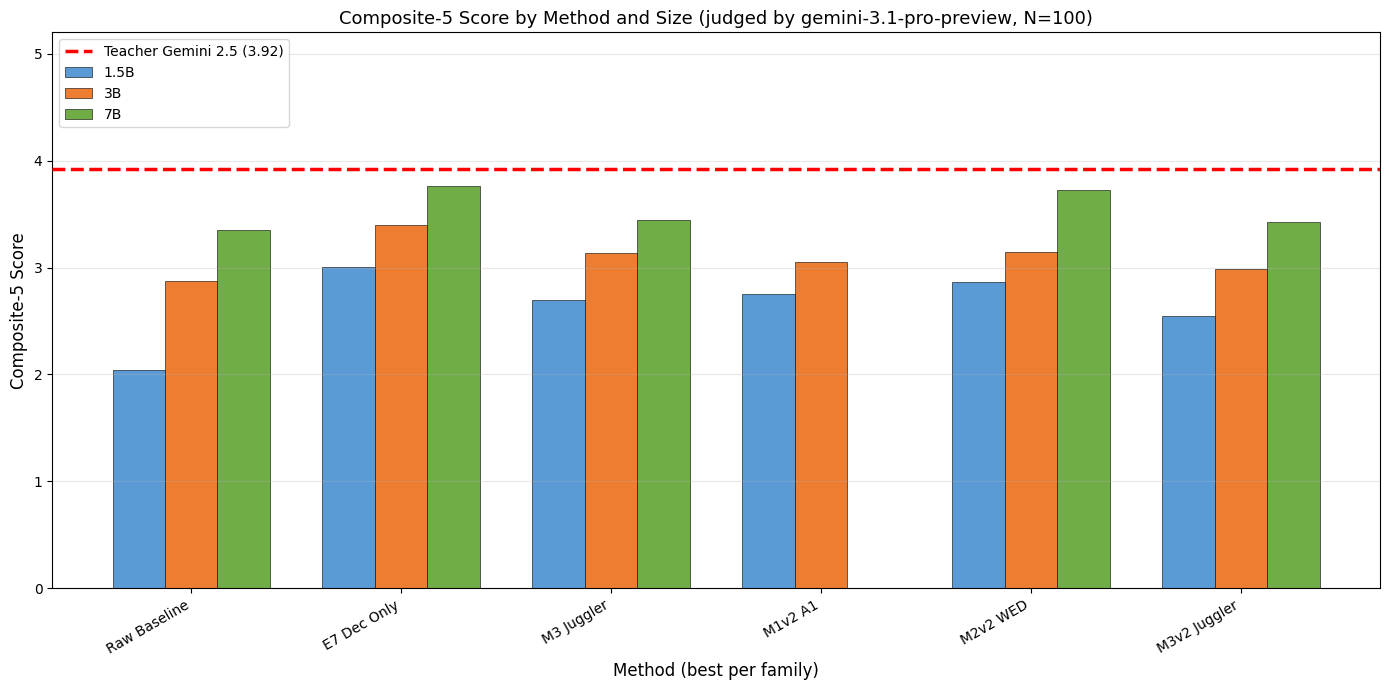

Saved: FIG1_composite5_by_method_size.png


In [48]:
# Cell I0: Headline figure — composite_5 by best-of-family × size
import matplotlib.pyplot as plt

# Pick best config from each family for plotting
plot_methods = []
for fam in ["Baseline", "E-series", "M v1", "M1v2 Additive", "M2v2 Sequential", "M3v2 Juggler", "M4 Metric-Guided"]:
    fdf = flat[flat["family"] == fam]
    if fdf.empty: continue
    # Pick the method with the best 7B (or any size if no 7B) composite_5
    best = fdf.sort_values("composite_5", ascending=False).iloc[0]
    plot_methods.append(best["method"])

# Get data for plotting
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(plot_methods))
width = 0.25

colors = {"1.5B": "#5B9BD5", "3B": "#ED7D31", "7B": "#70AD47"}
for i, size in enumerate(SIZE_ORDER):
    values = []
    for m in plot_methods:
        sub = flat[(flat["method"] == m) & (flat["size"] == size)]
        values.append(sub.iloc[0]["composite_5"] if not sub.empty else np.nan)
    ax.bar(x + (i-1)*width, values, width, label=size, color=colors[size], edgecolor="black", linewidth=0.4)

ax.axhline(y=teacher_mean["composite_5"], color="red", linestyle="--", linewidth=2.5,
           label=f"Teacher Gemini 2.5 ({teacher_mean['composite_5']:.2f})", zorder=10)

ax.set_xlabel("Method (best per family)", fontsize=12)
ax.set_ylabel("Composite-5 Score", fontsize=12)
ax.set_title(f"Composite-5 Score by Method and Size (judged by gemini-3.1-pro-preview, N=100)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(plot_methods, rotation=30, ha="right")
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 5.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG1_composite5_by_method_size.png"), dpi=150)
plt.show()
print("Saved: FIG1_composite5_by_method_size.png")

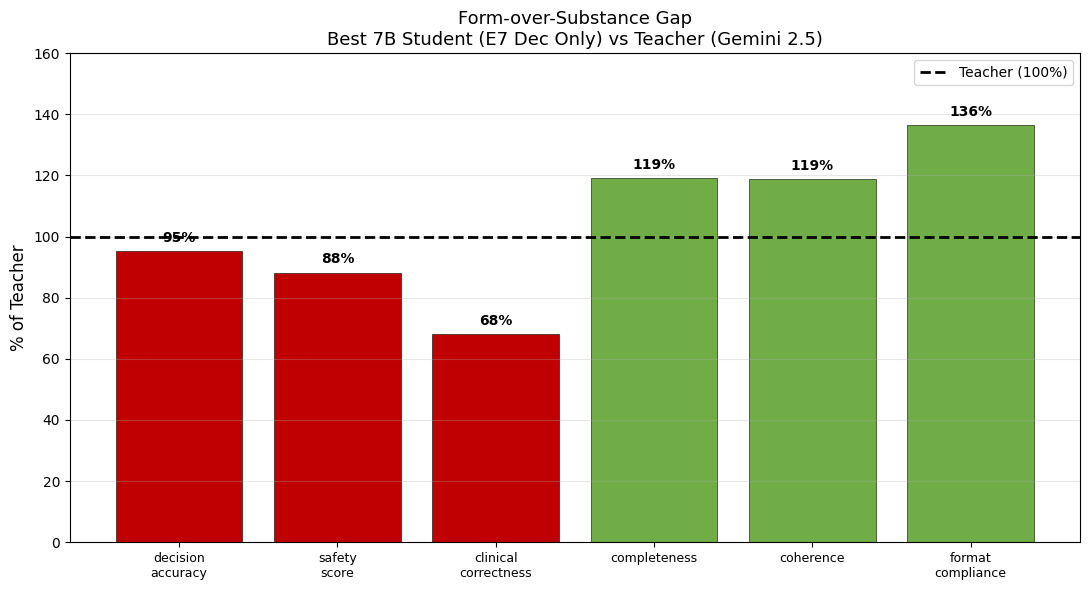

Saved: FIG2_form_over_substance.png


In [49]:
# Cell I1: Form-over-substance figure — best 7B vs teacher per metric
fig, ax = plt.subplots(figsize=(11, 6))

if not best_7b.empty:
    best_row = best_7b.iloc[0]
    metrics_for_plot = METRIC_COLS
    student_vals = [best_row[c] for c in metrics_for_plot]
    teacher_vals = [teacher_mean[c] for c in metrics_for_plot]
    pct_vals = [s/t*100 if t > 0 else 0 for s, t in zip(student_vals, teacher_vals)]
    
    x = np.arange(len(metrics_for_plot))
    bars = ax.bar(x, pct_vals, color=["#70AD47" if p > 100 else "#C00000" for p in pct_vals],
                   edgecolor="black", linewidth=0.4)
    ax.axhline(y=100, color="black", linestyle="--", linewidth=2, label="Teacher (100%)")
    
    # Annotate
    for bar, pct in zip(bars, pct_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{pct:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in metrics_for_plot], rotation=0, fontsize=9)
    ax.set_ylabel("% of Teacher", fontsize=12)
    ax.set_title(f"Form-over-Substance Gap\nBest 7B Student ({best_row['method']}) vs Teacher (Gemini 2.5)", fontsize=13)
    ax.set_ylim(0, max(160, max(pct_vals) + 15))
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG2_form_over_substance.png"), dpi=150)
plt.show()
print("Saved: FIG2_form_over_substance.png")

C:\Users\adishalit1\AppData\Local\Temp\ipykernel_23848\81554101.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


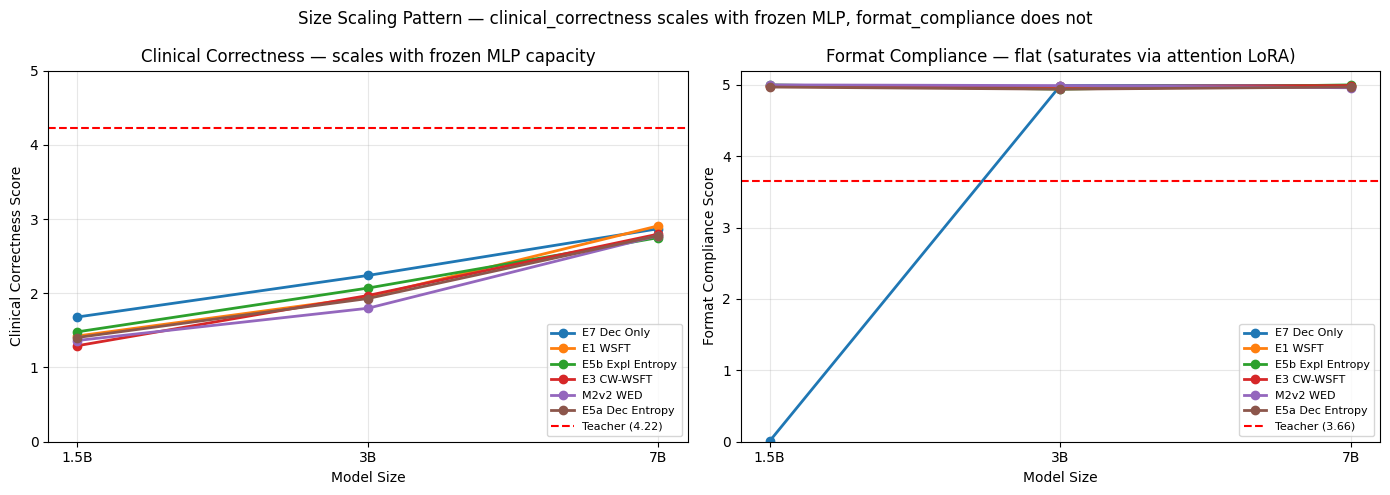

Saved: FIG3_size_scaling.png


In [50]:
# Cell I2: Size scaling figure — clinical_correctness vs format_compliance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pick top 6 methods by 7B composite_5
top6 = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).head(6)["method"].tolist()
cmap = plt.cm.get_cmap("tab10")

# Plot clinical_correctness scaling
for i, m in enumerate(top6):
    mdf = flat[flat["method"] == m].sort_values("size", key=lambda s: s.map(lambda x: SIZE_ORDER.index(x) if x in SIZE_ORDER else 999))
    sizes_present = mdf["size"].tolist()
    if len(sizes_present) < 2: continue
    axes[0].plot(sizes_present, mdf["clinical_correctness"].tolist(), marker="o", linewidth=2, label=m, color=cmap(i))
axes[0].axhline(y=teacher_mean["clinical_correctness"], color="red", linestyle="--", label=f"Teacher ({teacher_mean['clinical_correctness']:.2f})")
axes[0].set_title("Clinical Correctness — scales with frozen MLP capacity")
axes[0].set_xlabel("Model Size"); axes[0].set_ylabel("Clinical Correctness Score")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 5)

# Plot format_compliance scaling
for i, m in enumerate(top6):
    mdf = flat[flat["method"] == m].sort_values("size", key=lambda s: s.map(lambda x: SIZE_ORDER.index(x) if x in SIZE_ORDER else 999))
    sizes_present = mdf["size"].tolist()
    if len(sizes_present) < 2: continue
    axes[1].plot(sizes_present, mdf["format_compliance"].tolist(), marker="o", linewidth=2, label=m, color=cmap(i))
axes[1].axhline(y=teacher_mean["format_compliance"], color="red", linestyle="--", label=f"Teacher ({teacher_mean['format_compliance']:.2f})")
axes[1].set_title("Format Compliance — flat (saturates via attention LoRA)")
axes[1].set_xlabel("Model Size"); axes[1].set_ylabel("Format Compliance Score")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 5.2)

plt.suptitle("Size Scaling Pattern — clinical_correctness scales with frozen MLP, format_compliance does not", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG3_size_scaling.png"), dpi=150)
plt.show()
print("Saved: FIG3_size_scaling.png")

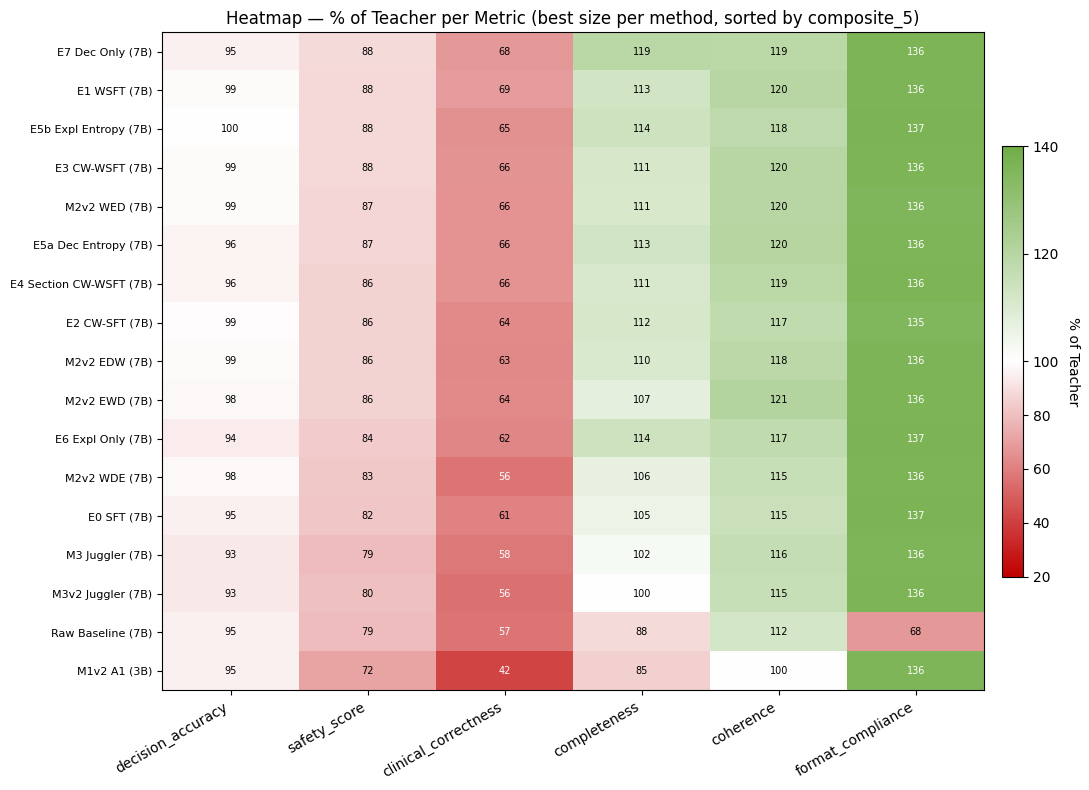

Saved: FIG4_heatmap_pct_teacher.png

→ Notice the systematic green stripe on right (format/coherence/completeness)
→ And the systematic red stripe on left (clinical_correctness, safety_score)


In [51]:
# Cell I3: Heatmap — methods × metrics as % of teacher
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# Build pct table (best size per method)
heatmap_rows = []
for method in flat["method"].unique():
    mdf = flat[flat["method"] == method]
    best_idx = mdf["composite_5"].idxmax()
    best_row = mdf.loc[best_idx]
    rec = {"method": f"{method} ({best_row['size']})"}
    for c in METRIC_COLS:
        rec[c] = (best_row[c] / teacher_mean[c] * 100) if teacher_mean[c] > 0 else 0
    rec["composite_5"] = (best_row["composite_5"] / teacher_mean["composite_5"] * 100)
    heatmap_rows.append(rec)

hdf = pd.DataFrame(heatmap_rows).set_index("method")
hdf = hdf.sort_values("composite_5", ascending=False)

fig, ax = plt.subplots(figsize=(11, max(8, len(hdf) * 0.32)))
data = hdf[METRIC_COLS].values

# Diverging colormap centered at 100
norm = TwoSlopeNorm(vmin=20, vcenter=100, vmax=140)
cmap = LinearSegmentedColormap.from_list("rwg", ["#C00000", "white", "#70AD47"])

im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(METRIC_COLS, rotation=30, ha="right")
ax.set_yticks(range(len(hdf)))
ax.set_yticklabels(hdf.index, fontsize=8)

# Cell annotations
for i in range(len(hdf)):
    for j in range(len(METRIC_COLS)):
        ax.text(j, i, f"{data[i,j]:.0f}", ha="center", va="center", fontsize=7,
                color="black" if 60 < data[i,j] < 130 else "white")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("% of Teacher", rotation=270, labelpad=15)
ax.set_title("Heatmap — % of Teacher per Metric (best size per method, sorted by composite_5)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG4_heatmap_pct_teacher.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: FIG4_heatmap_pct_teacher.png")
print("\n→ Notice the systematic green stripe on right (format/coherence/completeness)")
print("→ And the systematic red stripe on left (clinical_correctness, safety_score)")

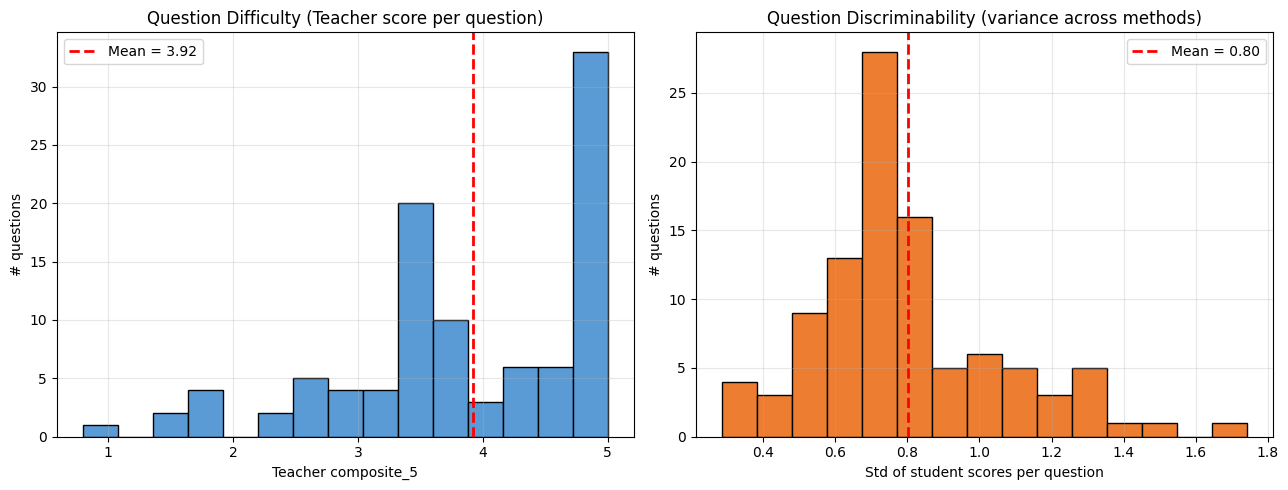

Saved: FIG5_question_distributions.png


In [52]:
# Cell I4: Question difficulty histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: distribution of teacher composite_5 across questions
if "teacher_comp5" in per_q.columns:
    axes[0].hist(per_q["teacher_comp5"].dropna(), bins=15, color="#5B9BD5", edgecolor="black")
    axes[0].axvline(per_q["teacher_comp5"].mean(), color="red", linestyle="--", linewidth=2,
                    label=f"Mean = {per_q['teacher_comp5'].mean():.2f}")
    axes[0].set_xlabel("Teacher composite_5")
    axes[0].set_ylabel("# questions")
    axes[0].set_title("Question Difficulty (Teacher score per question)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

# Right: distribution of std across methods per question (discriminability)
axes[1].hist(per_q["std_comp5"].dropna(), bins=15, color="#ED7D31", edgecolor="black")
axes[1].axvline(per_q["std_comp5"].mean(), color="red", linestyle="--", linewidth=2,
                label=f"Mean = {per_q['std_comp5'].mean():.2f}")
axes[1].set_xlabel("Std of student scores per question")
axes[1].set_ylabel("# questions")
axes[1].set_title("Question Discriminability (variance across methods)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG5_question_distributions.png"), dpi=150)
plt.show()
print("Saved: FIG5_question_distributions.png")

In [ ]:
# Cell I5: Final summary
print("="*90)
print("  FINAL ANALYSIS SUMMARY")
print("="*90)
print(f"  Total methods analyzed: {flat['method'].nunique()}")
print(f"  Total method × size combinations: {len(flat)}")
print(f"  Total questions per method: ~{N_EVAL}")
print(f"  Total student score rows: {len(master_df)}")
print(f"  Teacher: {len(teacher_df)} questions, mean composite_5 = {teacher_mean['composite_5']:.3f}")
print()

# Best overall
top_overall = flat.sort_values("composite_5", ascending=False).iloc[0]
print(f"  🏆 Best overall: {top_overall['method']} {top_overall['size']}")
print(f"     composite_5 = {top_overall['composite_5']:.3f} ({top_overall['composite_5']/teacher_mean['composite_5']*100:.1f}% of teacher)")
print()

# Key paper finding
print("  📊 KEY FINDING: Form-over-substance gap")
best_7b_row = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).iloc[0]
print(f"     Best 7B student: {best_7b_row['method']}")
print(f"     Format compliance: {best_7b_row['format_compliance']/teacher_mean['format_compliance']*100:.0f}% of teacher (exceeds)")
print(f"     Coherence:         {best_7b_row['coherence']/teacher_mean['coherence']*100:.0f}% of teacher (exceeds)")
print(f"     Clinical correctness: {best_7b_row['clinical_correctness']/teacher_mean['clinical_correctness']*100:.0f}% of teacher (LAGS)")
print(f"     Safety score:        {best_7b_row['safety_score']/teacher_mean['safety_score']*100:.0f}% of teacher (LAGS)")
print()
print("  ✅ All paper outputs saved to:", DATA_DIR)
print("     Tables: paper_top10.csv, paper_best_per_family.csv, PAPER_HEADLINE_form_over_substance.csv,")
print("             form_over_substance_per_metric.csv, size_scaling.csv,")
print("             per_question_stats.csv, top_methods_with_ci.csv, failure_cases.json")
print("     Plots:  FIG1_composite5_by_method_size.png")
print("             FIG2_form_over_substance.png")
print("             FIG3_size_scaling.png")
print("             FIG4_heatmap_pct_teacher.png")
print("             FIG5_question_distributions.png")

  FINAL ANALYSIS SUMMARY
  Total methods analyzed: 17
  Total method × size combinations: 50
  Total questions per method: ~100
  Total student score rows: 4958
  Teacher: 100 questions, mean composite_5 = 3.918

  🏆 Best overall: E7 Dec Only 7B
     composite_5 = 3.766 (96.1% of teacher)

  📊 KEY FINDING: Form-over-substance gap
     Best 7B student: E7 Dec Only
     Format compliance: 136% of teacher (exceeds)
     Coherence:         119% of teacher (exceeds)
     Clinical correctness: 68% of teacher (LAGS)
     Safety score:        88% of teacher (LAGS)

  ✅ All paper outputs saved to: C:\Users\adishalit1\Desktop\kd_project\data
     Tables: paper_top10.csv, paper_best_per_family.csv, PAPER_HEADLINE_form_over_substance.csv,
             form_over_substance_per_metric.csv, size_scaling.csv,
             per_question_stats.csv, top_methods_with_ci.csv, failure_cases.json
     Plots:  FIG1_composite5_by_method_size.png
             FIG2_form_over_substance.png
             FIG3_size_sc

: 